In [471]:
import math
import matplotlib.pyplot as plt
import numpy as np

In [472]:
SENSOR_VAR = 0.2
PROCESS_VAR = 0.1
VEL = 1.0
STEP = 25
DT = 0.1

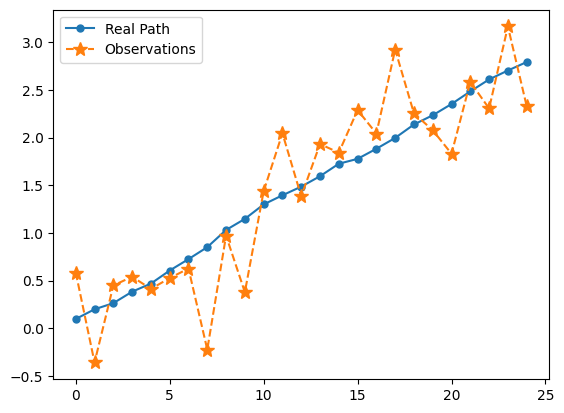

In [473]:
def simulate_realworld_neato(sensor_var, process_var, vel=1.0, step=1, dt=1.):
    """Simulates the movement of a Neato and measurement in the world.
    Input: 
        sensor_var
        process_var
        vel (float): velocity of the bot
        step (int): number of simulation snapshots
        dt (float): time delta between simulation snapshots
    Return:
        xs (array(float)): real positions
        zs (array(float)): observed positions
    """
    x = 0.  # initial position
    sensor_std = math.sqrt(sensor_var)  # compute sensor standard deviation from variance
    process_std = math.sqrt (process_var)  # compute process standard deviation from variance
    xs, zs = [] ,[]
    for i in range(step):
        v = vel + (np.random.randn() * process_std)
        x += v * dt  # simple velocity based update
        xs.append(x)
        zs.append(x + np.random.randn() * sensor_std)  # noise corrupted observation
    return np.array(xs), np.array(zs)

gt_xs, zs = simulate_realworld_neato(SENSOR_VAR, PROCESS_VAR, vel=VEL, step=STEP, dt=DT)
plt.plot(gt_xs, marker=".", ms=10, label="Real Path")
plt.plot(zs, linestyle="--", marker="*", ms=10, label="Observations")
plt.legend()
plt.show()

In [474]:
# Initial state covariance. 
# We know that the neato starts exactly at position 0, so there is no variance
# The velocity starts with the process variance included, which is also represented here
# There is no initial covariance
ps: list[np.ndarray] = [np.array([
    [0, 0          ],
    [0, PROCESS_VAR],
])]

# TBH I took this from the reading, but I'll try to explain what I understand from it.
# The thing we haven't modeled here is random acceleration. The variance is dt^2 * process_var 
# because variance is squared error. This makes squares the dt. The variance is already squared 
# error. The position is the integral, also with the constant terms squared for the same reason.
# The off diagonal terms are the expected value of the change in position multiplied by the same
# for velocity
q= np.array([
    [math.pow(DT, 4) / 4, math.pow(DT, 3) / 2],
    [math.pow(DT, 3) / 2, math.pow(DT, 2)],
]) * PROCESS_VAR

# Position changes by velocity * DT, everything else is constant
F = np.array([
    [1, DT],
    [0, 1 ],
])

# Measurements directly measure position
H = np.array([[1, 0]])

# We just have one sensor, so sensor noise is simple
R = np.array([[SENSOR_VAR]])

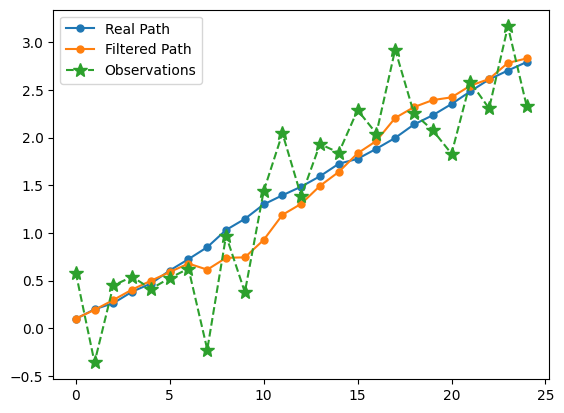

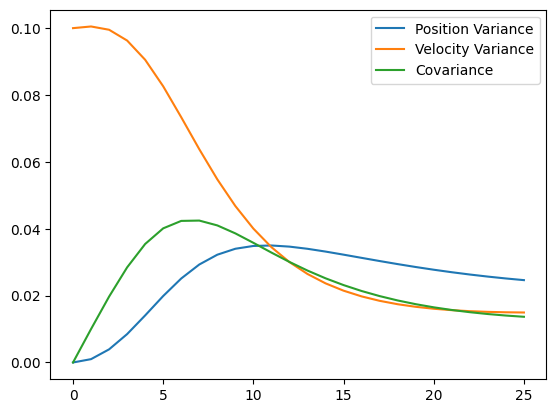

In [475]:
rng = np.random.default_rng()

filtered_xs: list[np.ndarray] = [np.array([0, VEL])]

for i in range(STEP):
    p = ps[-1]

    # Predict
    x_hat = F @ filtered_xs[i] # No actions and no noise
    p_hat = F @ p @ F.T + q

    # Update
    y = zs[i] - H @ x_hat
    s = H @ p_hat @ H.T + R
    k = p_hat @ H.T @ np.linalg.inv(s)

    filtered_xs.append(x_hat + k @ y)
    ps.append((np.identity(2) - k @ H) @ p_hat)

# Get rid of timestep 0 to match the ground truth data
filtered_xs.pop(0)

filtered_pos = [x[0] for x in filtered_xs]

plt.plot(gt_xs, marker=".", ms=10, label="Real Path")
plt.plot(filtered_pos, marker=".", ms=10, label="Filtered Path")
plt.plot(zs, linestyle="--", marker="*", ms=10, label="Observations")
plt.legend()
plt.show()

position_variance: list[float] = []
velocity_variance: list[float] = []
covariance: list[float] = []

for p in ps:
    position_variance.append(p[0, 0])
    velocity_variance.append(p[1, 1])
    covariance.append(p[1, 0])

plt.plot(position_variance, label="Position Variance")
plt.plot(velocity_variance, label="Velocity Variance")
plt.plot(covariance, label="Covariance")
plt.legend()
plt.show()

**How does the process covariance change with each iteration of the filter? What would the off-diagonal values indicate?**
> The process covariance generally decreases over time.
> However, since we know the exact position at the start and then noise is introduced, the uncertainty first grows.
> The off-diagonal values show the covariance between position and velocity. 
> It makes sense that there is some, because if the neato is going faster, it should end up farther.

**What impact does $R$ have on the quality of the Neato position estimate? What about $Q$?**
> $R$ is a measure of the sensor noise. 
> If the entries in $R$ are large, then the filter will trust the measurements less.
> When playing with different sensor noise values, I was surprised to see how similar the estimates looked regardless of the level of noise.
> However, this makes sense, because if the filter is expecting the correct amount of noise, it will trust the measurements exactly as much as it should.
> Real errors should arise when the actual level of noise and the values in $R$ are mismatched.<br> 
> $Q$ is a measure of the process noise, and represents unmodeled things in our system.
> It is really hard to define because, by definition, it takes into account things that are unmodeled.
> Oftentimes, we don't model things becuase we can't model them, or we don't even know about them.
> Coming up with quantities for these unmodeled things is therefore very difficult.
> In this case however, we know exactly what we aren't modeling, which is variation in the velocity, or random acceleration.
> Just with with $R$, if the entries in $Q$ are large, then the filter will trust the prediction less.
> Again, it is important to have reasonable values for $Q$, because otherwise the filter will not trust the prediction enough, or may trust it too much.

**If you were to add a noisy measurement of velocity at each timestep, what would need to be redefined about your model? How different would you expect the filter performance to be?**
> $H$ and $R$ would become 2x2 matrices instead of a 1x2 and 1x1. 
> We would also need to calculate the sensor covariance.
> There likely is some because velocity is related to position, although I'm not sure how much and what that calculation would look like.
> I would expect the filter performance to be significantly better since there would be much more information. 
> Not only this, but it would be direct information about velocity, which is where the noise is introduced.